# Übungsblatt Pandas GroupBy & Agg & Pivot_Table

Bei den nachfolgnenden Übungen geht es darum, die Pandas GroupBy und Agg Funktionen zu üben.

Dazu verwenden wir den bekannten Datensatz "titanic" aus dem seaborn Paket.

Diese Spalten sind im Datensatz enthalten:

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df = sns.load_dataset("titanic")

### 1. GroupBy

#### a)

Verschaffe dir einen Überblick über die ersten bzw. letzten 5 Zeilen des Datensatzes.

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


#### b)

Gruppiere die Daten nach der Spalte "class" und gebe den ersten und den letzten Eintrag der Gruppe aus

In [6]:
class_group = df.groupby("class", observed=False)

In [7]:
class_group.first()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,1,1,female,38.0,1,0,71.2833,C,woman,False,C,Cherbourg,yes,False
Second,1,2,female,14.0,1,0,30.0708,C,child,False,D,Cherbourg,yes,False
Third,0,3,male,22.0,1,0,7.2500,S,man,True,G,Southampton,no,False


In [8]:
class_group.last()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,embark_town,alive,alone
class,,,,,,,,,,,,,,
First,1,1,male,26.0,0,0,30.00,C,man,True,C,Cherbourg,yes,True
Second,0,2,male,27.0,0,0,13.00,S,man,True,E,Southampton,no,True
Third,0,3,male,32.0,0,0,7.75,Q,man,True,E,Queenstown,no,True


#### c)

Schaue dir die erste Klasse an, die Titanic gefahren ist. Liste alle Einträge dieser Klasse auf.

In [9]:
class_group.get_group("First")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


#### d)

Wir gruppieren den DataFrame zu erst nach "sex" und danach "alive".

In [10]:
survived_sex_group = df.groupby(["sex", "alive"])

survived_sex_group.first()

survived  pclass   age  sibsp  parch     fare embarked   class  \
sex    alive                                                                   
female no            0       3  14.0      0      0   7.8542        S   Third   
       yes           1       1  38.0      1      0  71.2833        C   First   
male   no            0       3  22.0      1      0   7.2500        S   Third   
       yes           1       2  34.0      0      0  13.0000        S  Second   

                who  adult_male deck  embark_town  alone  
sex    alive                                              
female no     child       False    C  Southampton   True  
       yes    woman       False    C    Cherbourg  False  
male   no       man        True    E  Southampton  False  
       yes      man        True    D  Southampton   True

#### e)

Nun möchten wir alle alle Männer ausgeben, die überlebt haben.

In [11]:
survived_sex_group.get_group(("male", "yes"))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
21,1,2,male,34.0,0,0,13.0000,S,Second,man,True,D,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
36,1,3,male,NaN,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,yes,True
55,1,1,male,NaN,0,0,35.5000,S,First,man,True,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
839,1,1,male,NaN,0,0,29.7000,C,First,man,True,C,Cherbourg,yes,True
857,1,1,male,51.0,0,0,26.5500,S,First,man,True,E,Southampton,yes,True
869,1,3,male,4.0,1,1,11.1333,S,Third,child,False,NaN,Southampton,yes,False


### 2. Aggregation

#### a)

Gruppiere die Daten nach der Spalte "class" und berechne den Durchschnitt der Spalten, die numerische Werte enthalten.

In [12]:
class_group[["pclass", "age", "fare"]].mean()

,pclass,age,fare
class,,,
First,1.0,38.233441,84.154687
Second,2.0,29.877630,20.662183
Third,3.0,25.140620,13.675550


#### b)

Schaue dir nochmals den nach Klasse gruppierten DataFrame an und verwende die Funktion "agg" um folgende Werte zu berechnen. Durchschnitt, Standardabweichung, Median, Min und Max

In [13]:
class_group[["pclass", "age", "fare"]].agg(["min", "mean", "median", "std", "max"])

pclass                        age                                     \
          min mean median  std max   min       mean median        std   max   
class                                                                         
First       1  1.0    1.0  0.0   1  0.92  38.233441   37.0  14.802856  80.0   
Second      2  2.0    2.0  0.0   2  0.67  29.877630   29.0  14.001077  70.0   
Third       3  3.0    3.0  0.0   3  0.42  25.140620   24.0  12.495398  74.0   

       fare                                           
        min       mean   median        std       max  
class                                                 
First   0.0  84.154687  60.2875  78.380373  512.3292  
Second  0.0  20.662183  14.2500  13.417399   73.5000  
Third   0.0  13.675550   8.0500  11.778142   69.5500

#### c)

Verwende die gleichen Aggregationsfunktionen jedoch nur auf die Spalten "age" und "fare".

In [14]:
class_group[["age", "fare"]].agg(["min", "mean", "median", "std", "max"])

age                                    fare                      \
         min       mean median        std   max  min       mean   median   
class                                                                      
First   0.92  38.233441   37.0  14.802856  80.0  0.0  84.154687  60.2875   
Second  0.67  29.877630   29.0  14.001077  70.0  0.0  20.662183  14.2500   
Third   0.42  25.140620   24.0  12.495398  74.0  0.0  13.675550   8.0500   

                             
              std       max  
class                        
First   78.380373  512.3292  
Second  13.417399   73.5000  
Third   11.778142   69.5500

#### d)

Schreibe eine Funktion `cheap(x)` der die Anzahl der Tickets ausgibt, die unter 10 kosten. Wende diese Funktion auf die Spalte "fare" an. Lasse dir auch den Durchschnitt, Standardabweichung, Median, Min und Max ausgeben.

In [15]:
def cheap(x):
    return (x < 5).sum()


class_group[["fare"]].agg(["min", "mean", "median", "std", "max", cheap])

fare                                               
        min       mean   median        std       max cheap
class                                                     
First   0.0  84.154687  60.2875  78.380373  512.3292     5
Second  0.0  20.662183  14.2500  13.417399   73.5000     6
Third   0.0  13.675550   8.0500  11.778142   69.5500     5

#### e)

Gruppiere den data frame nach "class", "who" und "alive" und zeige von "fare" den Durchschnitt, Standardabweichung, Median, Min und Max an.

In [16]:
grouped_df = df.groupby(["class", "who", "alive"], observed=False)

grouped_df["fare"].agg(["min", "mean", "median", "std", "max"])

min        mean     median         std       max
class  who   alive                                                       
First  child no     151.5500  151.550000  151.55000         NaN  151.5500
             yes     81.8583  136.949160  120.00000   48.364141  211.3375
       man   no       0.0000   62.894910   42.40000   60.052545  263.0000
             yes     26.2875   71.554074   35.50000  103.739456  512.3292
       woman no      28.7125   90.131250   90.13125   86.859229  151.5500
             yes     25.9292  104.636798   80.00000   74.717187  512.3292
Second child no          NaN         NaN        NaN         NaN       NaN
             yes     14.5000   28.323905   26.25000    7.750054   41.5792
       man   no       0.0000   19.488965   13.00000   15.720548   73.5000
             yes     10.5000   14.107812   13.00000    4.963091   26.0000
       woman no      10.5000   18.250000   17.00000    6.969577   26.0000
             yes     10.5000   21.130487   19.12500   11.330082   65.0000
Third  child no       7.2292   29.030179   29.12500   10.876604   46.9000
             yes      7.2250   15.551004   14.45420    6.430571   31.3875
       man   no       0.0000   10.793369    7.89580    9.480711   69.5500
             yes      0.0000   15.383987    7.98750   16.663692   56.4958
       woman no       6.7500   18.863293   14.45420   15.590348   69.5500
             yes      7.2250   11.720089    7.90210    5.740817   31.3875

#### f)

Nun möchten wir das was wir in Aufgabe 2d) tabellarisch dargestellt haben, auch grafisch darstellen. Verwende dafür Seaborns `catplot` und stelle die Daten in einem Boxplot dar.

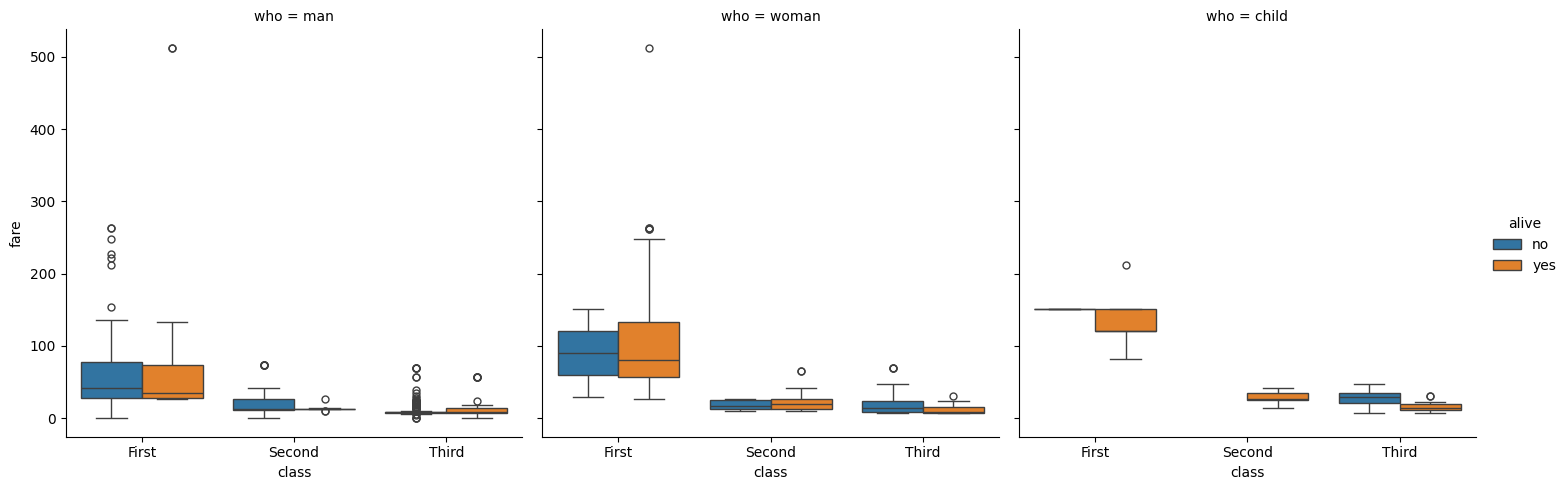

In [17]:
sns.catplot(data=df, x="class", y="fare", col="who", hue="alive", kind="box")

### 3. Transformation

Nun möchten noch eine gruppierte Transformation durchführen. Dazu verwenden wir die Funktion `transform`. Gruppiere den DataFrame nach "class" und subtrahiere den Durchschnitt der Spalte "age" von der Spalte "age".
Speichere das Ergebnis in einer neuen Spalte "age_diff".

In [18]:
df["age_diff"] = df.groupby("class", observed=False)["age"].transform(
    lambda x: x - x.mean()
)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_diff
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,-3.140620
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,-0.233441
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.859380
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,-3.233441
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,9.859380


### 4. Filter

Nun möchten wir die Daten filtern. Gruppiere den DataFrame nach "class" und filter die Daten so, dass nur die Klassen angezeigt werden, die mehr als 200 Einträge haben.

Überprüfe das Ergebnis, indem du die Anzahl der Einträge pro Klasse ausgibst.

In [ ]:
df.groupby("class", observed=False).filter(lambda x: len(x) > 200)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_diff
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,-3.140620
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,-0.233441
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.859380
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,-3.233441
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,9.859380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,13.859380
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,-19.233441
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,NaN
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,-12.233441


In [20]:
df.groupby("class", observed=False).size()

class
First     216
Second    184
Third     491
dtype: int64

### 5. Pivot

Nun möchten wir die Daten pivotieren. Gruppiere den DataFrame nach "class" und 
- zeige die Anzahl der Überlebenden pro Klasse an
- zeige das Durchschnittsalter der Überlebenden pro Klasse an

In [23]:
df.pivot_table(
    index="class",
    columns="alive",
    values=["survived", "age"],
    aggfunc={"survived": "count", "age": "mean"},
    observed=True,
)

age            survived     
alive          no        yes       no  yes
class                                     
First   43.695312  35.368197       80  136
Second  33.544444  25.901566       97   87
Third   26.555556  20.646118      372  119